# Animal Sounds Mode — YAMNet Classification
Animals: Dog | Cat | Bird | Frog
Model: YAMNet 

In [ ]:
!pip install -q tensorflow tensorflow-hub librosa soundfile matplotlib

In [ ]:
import os, json, zipfile, glob, csv
import numpy as np
import librosa
import soundfile as sf
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import Audio, display

SR      = 16000
OUT_DIR = 'animal_files'
os.makedirs(OUT_DIR, exist_ok=True)

ANIMALS = ['dog', 'cat', 'bird', 'frog']

ANIMAL_META = {
    'dog' : {'label': 'Dog',  'F0_range': (400,  1500), 'color': '#378ADD'},
    'cat' : {'label': 'Cat',  'F0_range': (760,  1500), 'color': '#D4537E'},
    'bird': {'label': 'Bird', 'F0_range': (1000, 8000), 'color': '#1D9E75'},
    'frog': {'label': 'Frog', 'F0_range': (500,  3000), 'color': '#EF9F27'},
}
print('Ready')

Ready


In [ ]:
from google.colab import files as colab_files
import subprocess

print('Upload your kaggle.json')
uploaded = colab_files.upload()
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(list(uploaded.values())[0].decode())
os.chmod('/root/.kaggle/kaggle.json', 0o600)

result = subprocess.run(
    ['kaggle', 'datasets', 'download', '-d',
     'maulanaakbardwijaya/animal-sounds-dataset',
     '--unzip', '-p', '/content/animal_data'],
    capture_output=True, text=True
)
print(result.stdout[-300:] if result.stdout else '')
if result.returncode != 0:
    print('Error:', result.stderr[-200:])
else:
    all_wavs = glob.glob('/content/animal_data/**/*.wav', recursive=True)
    all_mp3s = glob.glob('/content/animal_data/**/*.mp3', recursive=True)
    print(f'Downloaded. WAVs: {len(all_wavs)} | MP3s: {len(all_mp3s)}')

Upload your kaggle.json


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/maulanaakbardwijaya/animal-sounds-dataset
License(s): unknown


Downloaded. WAVs: 24 | MP3s: 0


In [ ]:
def load_clip(path, sr=16000, duration=3):
    audio, _ = librosa.load(path, sr=sr, mono=True)
    n = sr * duration
    audio = audio[:n] if len(audio) >= n else np.pad(audio, (0, n - len(audio)))
    return (audio / (np.max(np.abs(audio)) + 1e-8)).astype(np.float32)

all_audio_files = (
    glob.glob('/content/animal_data/**/*.wav', recursive=True) +
    glob.glob('/content/animal_data/**/*.mp3', recursive=True)
)
print(f'Total audio files found: {len(all_audio_files)}')
print('Sample paths:')
for f in all_audio_files[:10]:
    print(f'  {f}')

def find_animal_file(all_files, animal_name):
    keywords = {
        'dog' : ['dog', 'bark', 'canine'],
        'cat' : ['cat', 'meow', 'feline', 'kitten'],
        'bird': ['bird', 'tweet', 'chirp', 'sparrow', 'parrot', 'crow'],
        'frog': ['frog', 'toad', 'croak'],
    }
    kws = keywords.get(animal_name, [animal_name])
    for f in all_files:
        path_lower = f.lower()
        if any(kw in path_lower for kw in kws):
            return f
    return None

sounds    = {}
all_files_map = {}

for animal in ANIMALS:
    path = find_animal_file(all_audio_files, animal)
    if not path:
        print(f'{animal}: NOT FOUND in dataset')
        continue
    audio = load_clip(path, SR, 3)
    sounds[animal]        = audio
    all_files_map[animal] = path
    sf.write(f'{OUT_DIR}/{animal}.wav', audio, SR)
    print(f'{animal:6s} | {os.path.basename(path)} | shape={audio.shape}')

print(f'\nLoaded {len(sounds)}/4 animals: {list(sounds.keys())}')
if len(sounds) < 4:
    missing = [a for a in ANIMALS if a not in sounds]
    print(f'Missing: {missing}')
    print('Upload missing files manually in next cell')

Total audio files found: 24
Sample paths:
  /content/animal_data/Data Train/horse/horse2.wav
  /content/animal_data/Data Train/horse/horse1.wav
  /content/animal_data/Data Train/cat/cat1.wav
  /content/animal_data/Data Train/cat/cat2.wav
  /content/animal_data/Data Train/dog/dog1.wav
  /content/animal_data/Data Train/dog/dog_bark2.wav
  /content/animal_data/Data Train/dog/dog2.wav
  /content/animal_data/Data Train/dog/dog-bark3.wav
  /content/animal_data/Data Train/duck/duck1.wav
  /content/animal_data/Data Train/duck/duck2.wav
dog    | dog1.wav | shape=(48000,)
cat    | cat1.wav | shape=(48000,)
bird: NOT FOUND in dataset
frog: NOT FOUND in dataset

Loaded 2/4 animals: ['dog', 'cat']
Missing: ['bird', 'frog']
Upload missing files manually in next cell


In [ ]:
if len(sounds) < 4:
    missing = [a for a in ANIMALS if a not in sounds]
    print(f'Uploading missing animals: {missing}')
    print('Upload one WAV/MP3 file per animal in order:')

    from google.colab import files as colab_files
    for animal in missing:
        print(f'\nUpload sound for: {animal.upper()}')
        uploaded = colab_files.upload()
        fname    = list(uploaded.keys())[0]
        tmp_path = f'/tmp/{fname}'
        with open(tmp_path, 'wb') as f:
            f.write(uploaded[fname])
        audio = load_clip(tmp_path, SR, 3)
        sounds[animal] = audio
        sf.write(f'{OUT_DIR}/{animal}.wav', audio, SR)
        print(f'{animal} loaded | shape={audio.shape}')

    print(f'\nAll animals loaded: {list(sounds.keys())}')
else:
    print('All 4 animals loaded from dataset')

Uploading missing animals: ['bird', 'frog']
Upload one WAV/MP3 file per animal in order:

Upload sound for: BIRD


Saving mixkit-morning-birds-2472 (1).wav to mixkit-morning-birds-2472 (1).wav
bird loaded | shape=(48000,)

Upload sound for: FROG


Saving standard-toad-croaking-sound.mp3 to standard-toad-croaking-sound.mp3
frog loaded | shape=(48000,)

All animals loaded: ['dog', 'cat', 'bird', 'frog']


In [ ]:
print('Listen to each animal sound:\n')
for animal, audio in sounds.items():
    meta = ANIMAL_META[animal]
    print(f'{meta["label"]:6s} | F0 range: {meta["F0_range"][0]}–{meta["F0_range"][1]} Hz')
    display(Audio(audio, rate=SR))
    print()

Listen to each animal sound:

Dog    | F0 range: 400–1500 Hz



Cat    | F0 range: 760–1500 Hz



Bird   | F0 range: 1000–8000 Hz



Frog   | F0 range: 500–3000 Hz


In [ ]:
animal_list = [a for a in ANIMALS if a in sounds]
spk_list    = [sounds[a] for a in animal_list]
weight      = 1.0 / len(spk_list)
mixed       = sum(weight * s for s in spk_list).astype(np.float32)

mixed_path = f'{OUT_DIR}/mixed_animals.wav'
sf.write(mixed_path, mixed, SR)
print(f'Mixed {len(spk_list)} animals | Duration: 3s | SR: {SR} Hz')
print('\nMixed (all animals together):')
display(Audio(mixed, rate=SR))

Mixed 4 animals | Duration: 3s | SR: 16000 Hz

Mixed (all animals together):


In [ ]:
import urllib.request

print('Loading YAMNet from TensorFlow Hub...')
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')

# Download class map directly from GitHub
csv_url = 'https://raw.githubusercontent.com/tensorflow/models/master/research/audioset/yamnet/yamnet_class_map.csv'
urllib.request.urlretrieve(csv_url, 'yamnet_class_map.csv')

with open('yamnet_class_map.csv') as f:
    reader      = csv.DictReader(f)
    class_names = [r['display_name'] for r in reader]

print(f'YAMNet loaded — {len(class_names)} audio classes')

Loading YAMNet from TensorFlow Hub...
YAMNet loaded — 521 audio classes


In [ ]:
YAMNET_ANIMAL_KEYWORDS = {
    'dog' : ['dog', 'bark', 'bow-wow', 'growling'],
    'cat' : ['cat', 'meow', 'purr', 'hiss'],
    'bird': ['bird', 'chirp', 'tweet', 'crow', 'squawk', 'coo'],
    'frog': ['frog', 'croak', 'toad'],
}

def get_yamnet_animal_scores(audio, sr=16000):
    waveform = tf.cast(audio, tf.float32)
    scores, embeddings, spectrogram = yamnet_model(waveform)
    mean_scores = tf.reduce_mean(scores, axis=0).numpy()

    animal_scores = {}
    for animal, keywords in YAMNET_ANIMAL_KEYWORDS.items():
        matched = [
            mean_scores[i]
            for i, name in enumerate(class_names)
            if any(kw.lower() in name.lower() for kw in keywords)
        ]
        animal_scores[animal] = float(max(matched)) if matched else 0.0

    top5_idx = np.argsort(mean_scores)[::-1][:5]
    top5     = [(class_names[i], float(mean_scores[i])) for i in top5_idx]
    return animal_scores, top5

print('YAMNet analysis on individual animals:')
individual_scores = {}
for animal, audio in sounds.items():
    scores, top5 = get_yamnet_animal_scores(audio, SR)
    individual_scores[animal] = scores
    scores_str = ", ".join(f"{k}: {v:.3f}" for k, v in scores.items())
    print(f'\n{ANIMAL_META[animal]["label"]}:')
    print(f'  Animal scores: {scores_str}')
    print('  Top-5 YAMNet classes:')
    for name, score in top5:
        print(f'    {score:.3f}  {name}')

YAMNet analysis on individual animals:

Dog:
  Animal scores: dog: 0.797, cat: 0.002, bird: 0.005, frog: 0.000
  Top-5 YAMNet classes:
    0.861  Animal
    0.806  Domestic animals, pets
    0.797  Dog
    0.564  Bow-wow
    0.306  Yip

Cat:
  Animal scores: dog: 0.002, cat: 0.812, bird: 0.002, frog: 0.000
  Top-5 YAMNet classes:
    0.815  Animal
    0.812  Cat
    0.806  Domestic animals, pets
    0.734  Meow
    0.068  Inside, small room

Bird:
  Animal scores: dog: 0.000, cat: 0.000, bird: 0.899, frog: 0.000
  Top-5 YAMNet classes:
    0.901  Wild animals
    0.901  Animal
    0.899  Bird
    0.480  Bird vocalization, bird call, bird song
    0.474  Chirp, tweet

Frog:
  Animal scores: dog: 0.000, cat: 0.000, bird: 0.001, frog: 0.164
  Top-5 YAMNet classes:
    0.833  Silence
    0.164  Frog
    0.152  Croak
    0.136  Animal
    0.109  Wild animals


In [ ]:
print('YAMNet analysis on MIXED signal:')
mixed_scores, mixed_top5 = get_yamnet_animal_scores(mixed, SR)

print('Animal confidence scores in mixed signal:')
for animal, score in mixed_scores.items():
    bar = '#' * int(score * 40)
    print(f'  {ANIMAL_META[animal]["label"]:6s}: {score:.4f}  {bar}')

print('\nTop-5 YAMNet classes detected in mix:')
for name, score in mixed_top5:
    print(f'  {score:.3f}  {name}')

YAMNet analysis on MIXED signal:
Animal confidence scores in mixed signal:
  Dog   : 0.1123  ####
  Cat   : 0.3250  ############
  Bird  : 0.1090  ####
  Frog  : 0.1370  #####

Top-5 YAMNet classes detected in mix:
  0.700  Animal
  0.465  Domestic animals, pets
  0.325  Cat
  0.236  Meow
  0.188  Wild animals


In [ ]:
BANDS = {
    'Sub-bass (20-150Hz)' : (20,   150),
    'Low-mid (150-500Hz)' : (150,  500),
    'Mid (500-2kHz)'      : (500,  2000),
    'High-mid (2k-5kHz)'  : (2000, 5000),
    'High (5k-16kHz)'     : (5000, 16000),
}

def compute_band_energies(audio, sr=16000):
    fft_mag  = np.abs(np.fft.rfft(audio))
    freqs    = np.fft.rfftfreq(len(audio), 1.0 / sr)
    energies = {
        bname: float(np.sum(fft_mag[(freqs >= lo) & (freqs <= hi)] ** 2))
        for bname, (lo, hi) in BANDS.items()
    }
    total = sum(energies.values()) + 1e-12
    return {k: v / total for k, v in energies.items()}

band_results = {}
for animal, audio in sounds.items():
    band_results[animal] = compute_band_energies(audio, SR)

print('Band Energy per animal:')
for animal, energies in band_results.items():
    dominant = max(energies, key=energies.get)
    row = ' | '.join(f'{b.split("(")[0].strip()}: {v*100:.1f}%' for b, v in energies.items())
    print(f'  {animal:6s}: {row}  |  dominant → {dominant}')

Band Energy per animal:
  dog   : Sub-bass: 4.9% | Low-mid: 2.3% | Mid: 92.3% | High-mid: 0.5% | High: 0.0%  |  dominant → Mid (500-2kHz)
  cat   : Sub-bass: 0.1% | Low-mid: 0.4% | Mid: 7.5% | High-mid: 87.9% | High: 4.1%  |  dominant → High-mid (2k-5kHz)
  bird  : Sub-bass: 0.3% | Low-mid: 0.1% | Mid: 0.1% | High-mid: 98.9% | High: 0.5%  |  dominant → High-mid (2k-5kHz)
  frog  : Sub-bass: 0.2% | Low-mid: 0.2% | Mid: 22.4% | High-mid: 77.2% | High: 0.0%  |  dominant → High-mid (2k-5kHz)


In [ ]:
print('=' * 60)
print('EQUALIZER FREQUENCY BANDS — Animal Sounds')
print('=' * 60)

for animal in animal_list:
    meta     = ANIMAL_META[animal]
    energies = band_results[animal]
    dominant = max(energies, key=energies.get)

    print(f'\n{meta["label"]} | F0 range: {meta["F0_range"][0]}–{meta["F0_range"][1]} Hz')
    print(f'    {"Band":<24s}  {"Range (Hz)":>15s}  {"Energy":>7s}')
    print(f'    {"-" * 52}')
    for band_name, (lo, hi) in BANDS.items():
        pct  = energies[band_name] * 100
        flag = ' <- dominant' if band_name == dominant else ''
        print(f'    {band_name:<24s}  {lo:>5,} - {hi:<6,}  {pct:>6.1f}%{flag}')

print('\n' + '=' * 60)
print('SLIDER FREQUENCY RANGE MAPPING')
print('=' * 60)

for animal in animal_list:
    meta     = ANIMAL_META[animal]
    energies = band_results[animal]
    active   = [
        (bname, lo, hi, energies[bname])
        for bname, (lo, hi) in BANDS.items()
        if energies[bname] > 0.10
    ]
    ranges_str = ' + '.join(f'{lo:,}-{hi:,} Hz' for _, lo, hi, _ in active)
    print(f'\nSlider "{meta["label"]}" → {ranges_str}')
    for bname, lo, hi, w in active:
        print(f'    {lo:>6,} - {hi:<6,} Hz   weight = {w:.3f}  ({w*100:.1f}%)')

EQUALIZER FREQUENCY BANDS — Animal Sounds

Dog | F0 range: 400–1500 Hz
    Band                           Range (Hz)   Energy
    ----------------------------------------------------
    Sub-bass (20-150Hz)          20 - 150        4.9%
    Low-mid (150-500Hz)         150 - 500        2.3%
    Mid (500-2kHz)              500 - 2,000     92.3% <- dominant
    High-mid (2k-5kHz)        2,000 - 5,000      0.5%
    High (5k-16kHz)           5,000 - 16,000     0.0%

Cat | F0 range: 760–1500 Hz
    Band                           Range (Hz)   Energy
    ----------------------------------------------------
    Sub-bass (20-150Hz)          20 - 150        0.1%
    Low-mid (150-500Hz)         150 - 500        0.4%
    Mid (500-2kHz)              500 - 2,000      7.5%
    High-mid (2k-5kHz)        2,000 - 5,000     87.9% <- dominant
    High (5k-16kHz)           5,000 - 16,000     4.1%

Bird | F0 range: 1000–8000 Hz
    Band                           Range (Hz)   Energy
    ----------------------

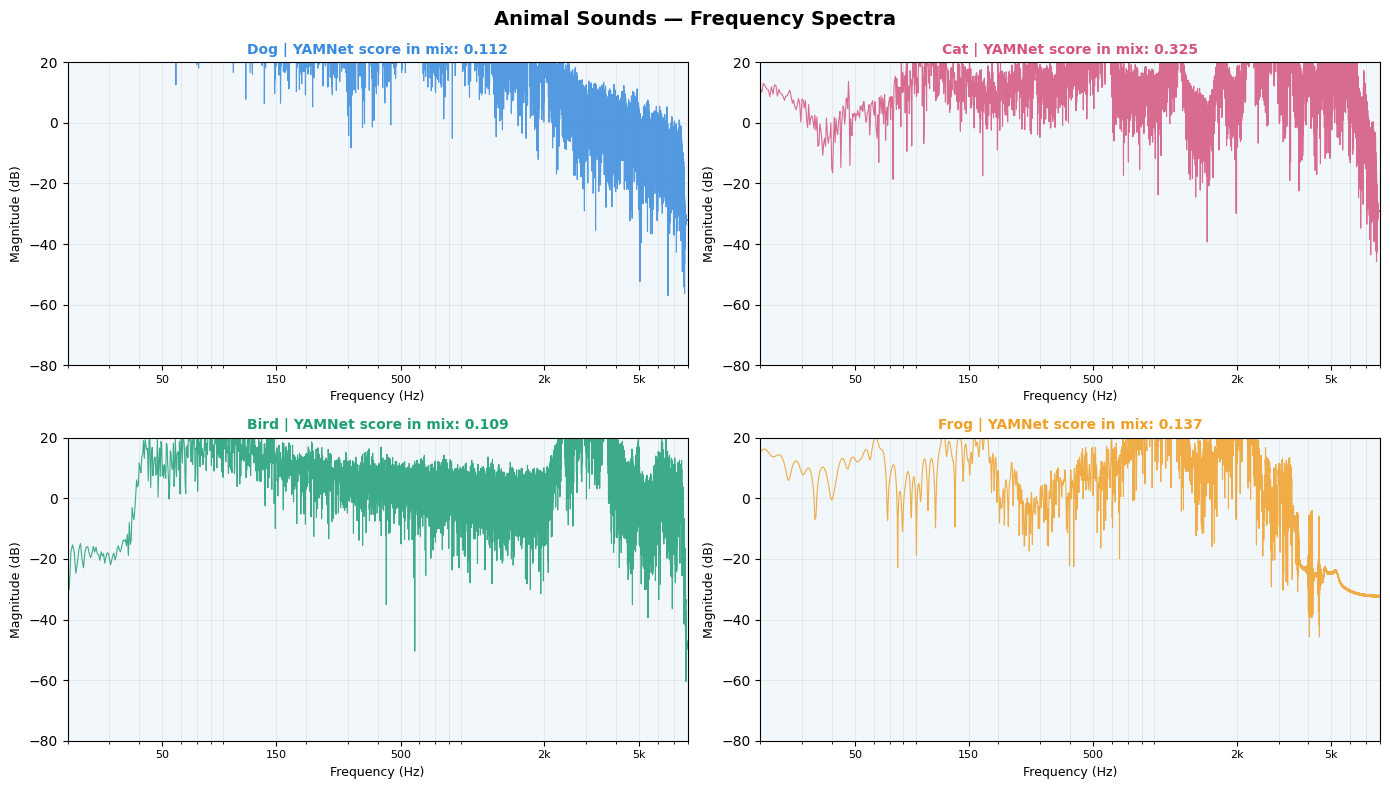

Saved → frequency_spectra.png


In [ ]:
colors = [ANIMAL_META[a]['color'] for a in animal_list]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Animal Sounds — Frequency Spectra', fontsize=14, fontweight='bold')

for ax, animal, color in zip(axes.flat, animal_list, colors):
    audio = sounds[animal]
    fft   = np.abs(np.fft.rfft(audio))
    freqs = np.fft.rfftfreq(len(audio), 1.0 / SR)
    dB    = 20 * np.log10(fft + 1e-8)

    ax.plot(freqs, dB, color=color, linewidth=0.8, alpha=0.85)

    for band_name, (lo, hi) in BANDS.items():
        ax.axvspan(lo, hi, alpha=0.06)

    meta     = ANIMAL_META[animal]
    yamnet_s = mixed_scores.get(animal, 0)
    ax.set_title(f'{meta["label"]} | YAMNet score in mix: {yamnet_s:.3f}',
                 fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('Frequency (Hz)', fontsize=9)
    ax.set_ylabel('Magnitude (dB)', fontsize=9)
    ax.set_xscale('log')
    ax.set_xlim(20, SR // 2)
    ax.set_ylim(-80, 20)
    ax.grid(True, alpha=0.3, linewidth=0.5, which='both')
    ax.set_xticks([50, 150, 500, 2000, 5000])
    ax.set_xticklabels(['50', '150', '500', '2k', '5k'], fontsize=8)

plt.tight_layout()
plt.savefig('frequency_spectra.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → frequency_spectra.png')

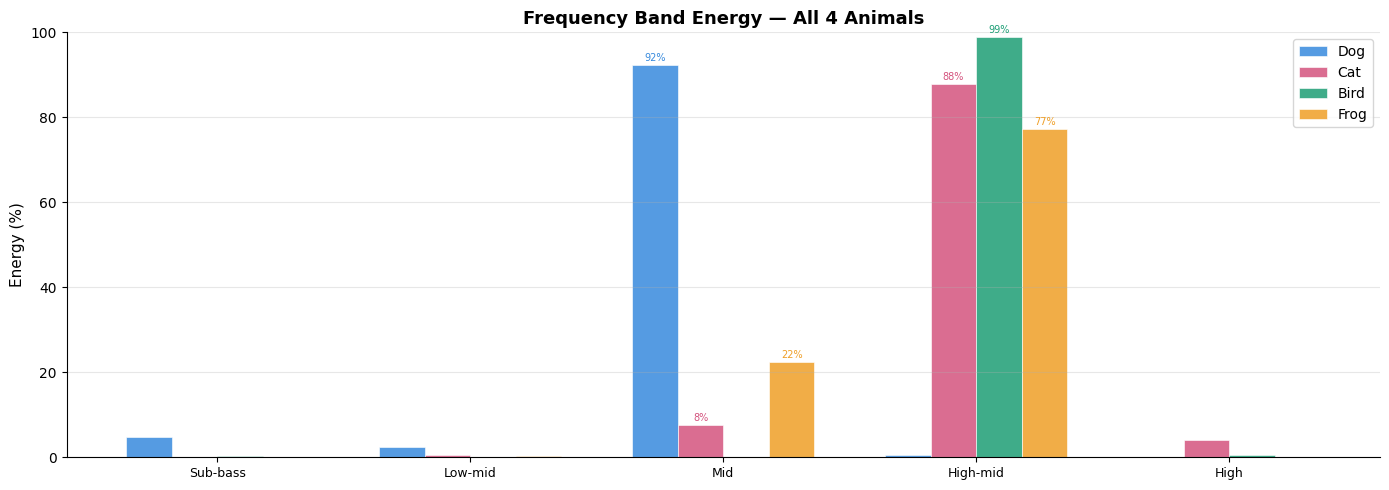

Saved → band_energy_comparison.png


In [ ]:
band_names = list(BANDS.keys())
x          = np.arange(len(band_names))
width      = 0.18

fig, ax = plt.subplots(figsize=(14, 5))

for j, (animal, color) in enumerate(zip(animal_list, colors)):
    values = [band_results[animal][b] * 100 for b in band_names]
    offset = (j - 1.5) * width
    bars   = ax.bar(x + offset, values, width,
                    label=ANIMAL_META[animal]['label'],
                    color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, values):
        if val > 5:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val:.0f}%', ha='center', va='bottom', fontsize=7, color=color)

ax.set_xticks(x)
ax.set_xticklabels([b.split('(')[0].strip() for b in band_names], fontsize=9)
ax.set_ylabel('Energy (%)', fontsize=11)
ax.set_title('Frequency Band Energy — All 4 Animals', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('band_energy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → band_energy_comparison.png')

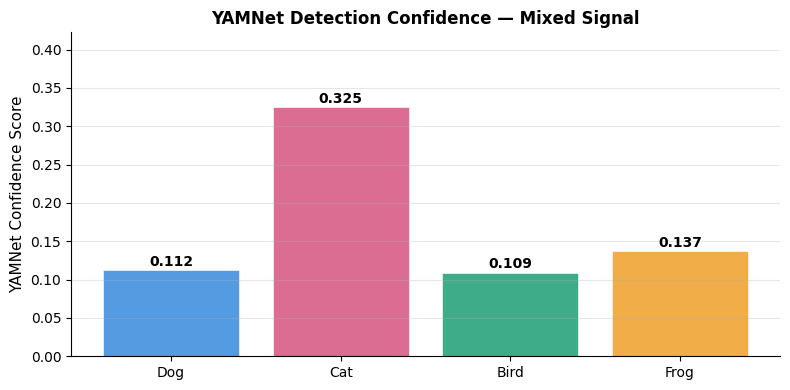

Saved → yamnet_scores.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

animals_plot = list(mixed_scores.keys())
scores_plot  = [mixed_scores[a] for a in animals_plot]
colors_plot  = [ANIMAL_META[a]['color'] for a in animals_plot]
labels_plot  = [ANIMAL_META[a]['label'] for a in animals_plot]

bars = ax.bar(labels_plot, scores_plot, color=colors_plot, alpha=0.85,
              edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, scores_plot):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('YAMNet Confidence Score', fontsize=11)
ax.set_title('YAMNet Detection Confidence — Mixed Signal', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(scores_plot) * 1.3)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('yamnet_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → yamnet_scores.png')

In [ ]:
config = {
    'mode'       : 'animal_sounds',
    'model'      : 'google/yamnet (tensorflow-hub)',
    'sample_rate': SR,
    'num_animals': len(sounds),
    'yamnet_mixed_scores': {a: round(mixed_scores[a], 4) for a in animal_list},
    'animals'    : []
}

for animal in animal_list:
    meta     = ANIMAL_META[animal]
    energies = band_results[animal]
    dominant = max(energies, key=energies.get)

    freq_windows = [
        {'low': lo, 'high': hi, 'weight': round(energies[b], 4)}
        for b, (lo, hi) in BANDS.items()
        if energies[b] > 0.05
    ]

    config['animals'].append({
        'key'              : animal,
        'label'            : meta['label'],
        'f0_range_hz'      : list(meta['F0_range']),
        'source_file'      : f'{animal}.wav',
        'yamnet_score'     : round(mixed_scores.get(animal, 0), 4),
        'dominant_band'    : dominant,
        'band_energies_pct': {k: round(v*100, 1) for k, v in energies.items()},
        'freq_windows'     : freq_windows,
    })

with open('animal_mode_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('Config saved → animal_mode_config.json')
print(json.dumps(config, indent=2))

Config saved → animal_mode_config.json
{
  "mode": "animal_sounds",
  "model": "google/yamnet (tensorflow-hub)",
  "sample_rate": 16000,
  "num_animals": 4,
  "yamnet_mixed_scores": {
    "dog": 0.1123,
    "cat": 0.325,
    "bird": 0.109,
    "frog": 0.137
  },
  "animals": [
    {
      "key": "dog",
      "label": "Dog",
      "f0_range_hz": [
        400,
        1500
      ],
      "source_file": "dog.wav",
      "yamnet_score": 0.1123,
      "dominant_band": "Mid (500-2kHz)",
      "band_energies_pct": {
        "Sub-bass (20-150Hz)": 4.9,
        "Low-mid (150-500Hz)": 2.3,
        "Mid (500-2kHz)": 92.3,
        "High-mid (2k-5kHz)": 0.5,
        "High (5k-16kHz)": 0.0
      },
      "freq_windows": [
        {
          "low": 500,
          "high": 2000,
          "weight": 0.9229
        }
      ]
    },
    {
      "key": "cat",
      "label": "Cat",
      "f0_range_hz": [
        760,
        1500
      ],
      "source_file": "cat.wav",
      "yamnet_score": 0.325,
      

In [ ]:
from google.colab import files as colab_files

output_files = (
    glob.glob(f'{OUT_DIR}/*.wav') +
    ['frequency_spectra.png',
     'band_energy_comparison.png',
     'yamnet_scores.png',
     'animal_mode_config.json']
)

with zipfile.ZipFile('animal_outputs.zip', 'w') as zf:
    for fp in output_files:
        if os.path.exists(fp):
            zf.write(fp)
            print(f'+ {fp}')

colab_files.download('animal_outputs.zip')

+ animal_files/cat.wav
+ animal_files/frog.wav
+ animal_files/mixed_animals.wav
+ animal_files/bird.wav
+ animal_files/dog.wav
+ frequency_spectra.png
+ band_energy_comparison.png
+ yamnet_scores.png
+ animal_mode_config.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>